# ¿Cómo vamos a entrenar las RN?

Este notebook se centra en comparar los distintos algoritmos de optimización vistos en clase. El código descarga y preprocesa los datos, define el modelo (vamos a usar una regresión lineal simple para aislar el efecto del opimizador)

¿Qué datos vamos a usar?
`airfoil_self_noise.dat`: datos sobre ruido aerodinámico de perfiles alares. Cada fila tiene 6 columnas (5 features y la etiqueta). Las features son frecuencia de la medición, angulo de ataque, longitud de la cuerda, velocidad de fllujo, espesores y la etiqueta que es el nivel de presión sonora. 



In [1]:
## primero cargamos los datos: 
import io
import numpy as np
import torch

def load_airfoil(n=1500, url=None, use_requests=False):
    """
    Descarga y procesa airfoil_self_noise.dat. Devuelve X_t, y_t (torch.float32).
    - n: número de filas a usar (si n > filas disponibles, usa todas)
    - url: opcional string con URL; si None se usa la URL del UCI repo
    - use_requests: si True usa requests (si está instalado); si False usa urllib
    """
    if url is None:
        url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'

    # 1 Descargar de forma segura y convertir a numpy array
    try:
        if use_requests:
            import requests
            resp = requests.get(url, timeout=20)
            resp.raise_for_status()
            raw = resp.content
            data = np.loadtxt(io.BytesIO(raw))
        else:
            # urllib es parte de la stdlib y devuelve un file-like object
            from urllib.request import urlopen
            with urlopen(url, timeout=20) as f:
                # np.loadtxt acepta un file-like object
                data = np.loadtxt(f)
    except Exception as e:
        raise RuntimeError(f"Error descargando/leyendo el archivo desde {url}: {e}")

    # 2 Protección: validar forma
    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError("Formato inesperado del dataset. Esperamos una matriz (n_samples, n_features+1)")

    # 3 Sub-muestreo (si se pide menos filas)
    if n is not None:
        n = min(n, data.shape[0])
        data = data[:n, :]

    # 4 Normalización por columna (whitening simple: mean 0, std 1)
    #    Aplicar sobre todas las columnas (incluye target). Algunas veces d2l normaliza inputs y target.
    X = data[:, :-1].astype(np.float32)
    y = data[:, -1].astype(np.float32).reshape(-1, 1)

    # Normalizar X y y: importante para la convergencia de optimizadores
    X_mean, X_std = X.mean(axis=0, keepdims=True), X.std(axis=0, keepdims=True)
    y_mean, y_std = y.mean(axis=0, keepdims=True), y.std(axis=0, keepdims=True)

    # Evitar división por cero
    X_std[X_std == 0] = 1.0
    if y_std == 0:
        y_std = 1.0

    X = (X - X_mean) / X_std
    y = (y - y_mean) / y_std

    # Convertir a tensores de torch (float32)
    X_t = torch.from_numpy(X)
    y_t = torch.from_numpy(y)

    # también devolvemos los estadísticos para poder des-normalizar resultados si se desea
    stats = {
        'X_mean': X_mean.reshape(-1).astype(np.float32),
        'X_std': X_std.reshape(-1).astype(np.float32),
        'y_mean': float(y_mean),
        'y_std': float(y_std)
    }

    return X_t, y_t, stats


In [2]:
## Nos aseguramos que los datos si esten cargados: 

X_all, y_all, stats = load_airfoil(n=1500, use_requests=False)
print("Shape X:", X_all.shape, "Shape y:", y_all.shape)
print("Stats (y mean,std):", stats['y_mean'], stats['y_std'])
# Comprobar que X tiene media ~0 y std ~1 por columna
print("X col means (approx):", X_all.mean(dim=0).numpy())
print("X col stds  (approx):", X_all.std(dim=0).numpy())

Shape X: torch.Size([1500, 5]) Shape y: torch.Size([1500, 1])
Stats (y mean,std): 124.87425994873047 6.849607467651367
X col means (approx): [ 6.3578289e-09  3.0263266e-06  3.2246908e-06 -1.6845068e-05
 -3.9672852e-07]
X col stds  (approx): [1.0003338 1.0003347 1.0003413 1.0003359 1.0003325]


/var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/ipykernel_28372/1500221458.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'y_mean': float(y_mean),
/var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/ipykernel_28372/1500221458.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'y_std': float(y_std)


/var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/ipykernel_28372/1500221458.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'y_mean': float(y_mean),
/var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/ipykernel_28372/1500221458.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  'y_std': float(y_std)


Ejemplos: torch.Size([1500, 5]) -> feature_dim = 5
Corriendo GD | lr=1.0 | batch_size=1500
Corriendo SGD | lr=0.005 | batch_size=1
Corriendo SGD_momentum | lr=0.03 | batch_size=32
Corriendo RMSprop | lr=0.01 | batch_size=32
Corriendo Adam | lr=0.01 | batch_size=32


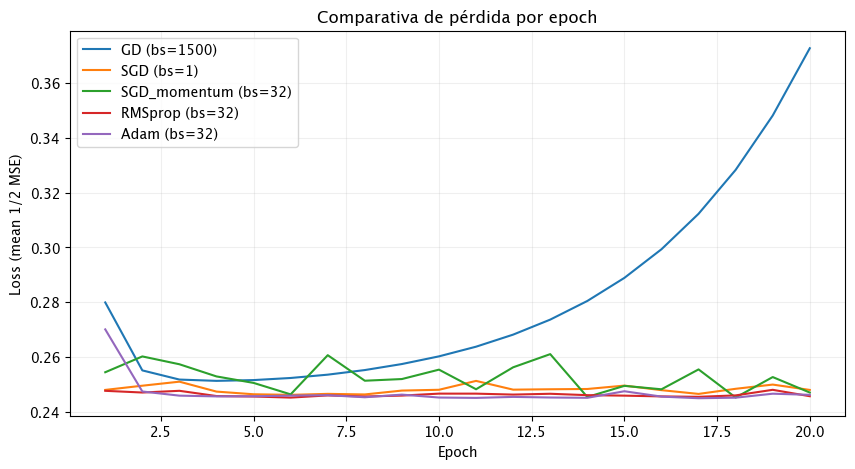

GD: avg time/epoch = 0.0057s, final loss = 0.372665
SGD: avg time/epoch = 0.1215s, final loss = 0.248055
SGD_momentum: avg time/epoch = 0.0065s, final loss = 0.247107
RMSprop: avg time/epoch = 0.0072s, final loss = 0.245762
Adam: avg time/epoch = 0.0076s, final loss = 0.246270


In [3]:
# Comparativa optimizadores (PyTorch) — dataset: airfoil_self_noise (ejemplo d2l)
# Requisitos: torch, numpy, matplotlib
# -----------------------------------------------------------
# Importaciones principales
# -----------------------------------------------------------
import time                # para medir tiempos de entrenamiento por época
import numpy as np         # utilidades numéricas (normalización, medias, std)
import torch               # PyTorch: tensores y autograd
import torch.nn as nn      # módulos de redes (Linear, inicializadores, etc.)
from torch.utils.data import TensorDataset, DataLoader  # utilidades de datos
import matplotlib.pyplot as plt  # para graficar resultados
from urllib.request import urlopen  # usado en la función de carga (si necesario)
import io                 # para manejo de bytes/file-like si descargamos desde la web


# load_airfoil() es la función robusta que definimos antes (descarga, normaliza y
# devuelve X_all (features), y_all (target) y stats para des-normalizar si se desea).
# Aquí llamamos la función y extraemos la dimensión de las características.
X_all, y_all, stats = load_airfoil(n=1500, use_requests=False)

# feature_dim: número de columnas/features de entrada (en este dataset = 5)
feature_dim = X_all.shape[1]

# Mensaje informativo para confirmar que la carga fue exitosa
print("Ejemplos:", X_all.shape, "-> feature_dim =", feature_dim)
# Ejemplo de salida esperada: Ejemplos: torch.Size([1500, 5]) -> feature_dim = 5

def reset_seeds(seed=0):
    """
    Fija semillas de numpy y torch para reproducibilidad.
    IMPORTANTE: si corres en GPU, conviene fijar torch.cuda.manual_seed_all(seed).
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

def init_linear(model):
    """
    Inicialización de pesos:
      - pesos (matrices) ~ Normal(0, 0.01)
      - bias = 0
    Hacer una inicialización conocida nos permite comparar
    el efecto de los optimizadores cuando repetimos experimentos.
    """
    for p in model.parameters():
        if p.ndim > 1:
            # p.ndim > 1 identifica matrices de pesos (ej. [out, in])
            nn.init.normal_(p, mean=0.0, std=0.01)
        else:
            # vectores (bias) inicializados a 0
            nn.init.zeros_(p)

# -----------------------------------------------------------
# Funciones de pérdida y evaluación
# -----------------------------------------------------------
def squared_loss(y_hat, y):
    return 0.5 * (y_hat - y) ** 2

def evaluate_loss(model, X, y, loss_fn):
    """
    Evalúa la pérdida media sobre todo el conjunto (modo evaluación sin gradientes).
    Esto nos permite rastrear la pérdida "global" por época, independiente del
    ruido introducido por los minibatches durante el entrenamiento.
    """
    model.eval()  # modo evaluación: afecta a capas como dropout / batchnorm (no hay aquí)
    with torch.no_grad():  # desactiva autograd para eficiencia
        return loss_fn(model(X), y).mean().item()


def run_training(optimizer_name, lr, batch_size, num_epochs=20, momentum=0.9):
    """
    Corre el experimento con la configuración dada y devuelve:
       - losses: lista de pérdidas evaluadas al final de cada epoch (pérdida media sobre todo el dataset)
       - epoch_times: lista con tiempo consumido en cada epoch (segundos)
       - model: modelo final entrenado (útil para inspección posterior)
    Parámetros:
      optimizer_name: 'GD', 'SGD', 'SGD_momentum', 'RMSprop', 'Adam'
      lr: learning rate
      batch_size: tamaño del minibatch (si batch_size == n => full-batch / GD)
      num_epochs: número de épocas a ejecutar
      momentum: parámetro beta para SGD con momentum (si aplica)
    """

    reset_seeds(42)  # fija semillas antes de construir el modelo para iniciar igual
    model = nn.Linear(feature_dim, 1)  # modelo lineal simple: salida escalar
    init_linear(model)                 # inicializar pesos de forma controlada
    # NOTA: usamos torch.optim.* por simplicidad. Para 'GD' tratamos igual que SGD,
    # la diferencia real la generamos con batch_size = n (full dataset) en el DataLoader.
    if optimizer_name == 'GD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD_momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name desconocido: elige GD/SGD/SGD_momentum/RMSprop/Adam")

    # Creamos un TensorDataset con X_all,y_all y el DataLoader con shuffle=True
    # shuffle=True es importante para SGD / minibatch para romper correlaciones temporales
    dataset = TensorDataset(X_all, y_all)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []        # pérdida global por época
    epoch_times = []   # tiempo consumido por época
    loss_fn = squared_loss  # función de pérdida local (no reducimos aquí)

    for epoch in range(1, num_epochs + 1):
        model.train()   # modo entrenamiento (afecta BatchNorm/Dropout, si existieran)
        t0 = time.time()  # tiempo de inicio para medir duración de epoch

        # iterar sobre minibatches del DataLoader
        for Xb, yb in loader:
            optimizer.zero_grad()        # poner gradientes a cero antes de backward
            y_hat = model(Xb)            # forward: predicciones sobre minibatch
            loss = loss_fn(y_hat, yb).mean()  # loss media del minibatch (scalar)
            loss.backward()              # backward: calcula gradientes dL/dθ
            optimizer.step()             # update: aplica regla del optimizador

        # medir tiempo de la epoch
        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)

        # Evaluar la pérdida sobre TODO el dataset (pérdida "global" de la epoch)
        epoch_loss = evaluate_loss(model, X_all, y_all, loss_fn)
        losses.append(epoch_loss)

    # devolvemos la historia de pérdidas, tiempos y el modelo entrenado
    return losses, epoch_times, model

num_epochs = 20               # cuántas épocas correremos para comparar
n = X_all.shape[0]            # número total de ejemplos (para full-batch)

# experiments: lista de tuplas (nombre, lr, batch_size)
# Notas:
#  - para 'GD' usamos batch_size = n para simular full-batch gradient descent.
#  - las tasas de aprendizaje (lr) están elegidas empíricamente: GD necesita lr mayor
#    (porque la varianza de la estimación del gradiente es 0 y la escala es distinta).
experiments = [
    ('GD', 1.0, n),             # full-batch GD (lr grande)
    ('SGD', 0.005, 1),          # SGD puro (batch=1): muy ruidoso
    ('SGD_momentum', 0.03, 32), # mini-batch + momentum
    ('RMSprop', 0.01, 32),      # RMSProp: normaliza por acumulado de grad^2
    ('Adam', 0.01, 32)          # Adam: momentum adaptativo + normalización
]

results = {}
for name, lr, bs in experiments:
    print(f"Corriendo {name} | lr={lr} | batch_size={bs}")
    losses, times, model = run_training(name, lr, bs, num_epochs=num_epochs)
    results[name] = {
        'losses': losses,
        'times': times,
        'lr': lr,
        'bs': bs
    }

plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(range(1, num_epochs + 1),
             results[name]['losses'],
             label=f"{name} (bs={results[name]['bs']})")
plt.xlabel('Epoch')
plt.ylabel('Loss (mean 1/2 MSE)')
plt.title('Comparativa de pérdida por epoch')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

for name in results:
    avg_t = np.mean(results[name]['times'])
    final_loss = results[name]['losses'][-1]
    print(f"{name}: avg time/epoch = {avg_t:.4f}s, final loss = {final_loss:.6f}")


¿Cómo interpretamos esto? 

1. Interpretación rápida de resultados esperados:
    - GD (full-batch): curvas suaves, baja varianza, pero por época puede ser más lento  en tiempo si no se vectoriza bien; buena estabilidad pero peor escalabilidad
    - SGD (batch=1): actualizaciones muy ruidosas -> curvas con mucha varianza. Cada paso es barato computacionalmente pero el ruido puede dificultar la convergencia.
    - SGD + momentum: mantiene la velocidad de SGD pero reduce oscilaciones, mejora convergencia.
    - RMSprop: adapta la magnitud del paso por coordenada según historial de gradientes.
    - Adam: combina momentum adaptativo + normalización; converge rápido en práctica.